# Lab 5: EDA - Multivariate Analysis
**Author:** 
**Date:** 2026-04-27

___

#### Topic Outline:

- Exploratory Data Analaysis:
  - Multivariate analysis:
    - Grouped tabulations of categorical and quantitative variables.
    - Visualizations for exploring relationships with dependent variables.

---

#### Collaboration

You are encouraged to collaborate with other students in your labs, but you are expected to write up your own work for submission.  Please do not copy and paste other people's solutions to problems as it is considered plagiarism and you will be penalized and reported.  Should you choose to collaborate with others, please note their names here:

**Your name:** 

**Collaborators:**

1.

___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your lab assignments and to enhance your learning experience.  Please make a note of any agents you have used in this submission here:

**Agents:** 

---

## 1. Introduction

Last week in Lab 4 we began our exploration of the `student_performance.csv` data set.  We specifically performed some univariate analysis of both categorical and quantitative variables, inspecting their summary statistics and producing visualization of their distribution.  This week we will continue our exploration but this time focussing on bivariate and multivariate relationships.  We again emphasize that our variable of interest is `final_scores` and so we taylor our exploration to specifically inspect the data for underlying relationships with `final_scores`.

For this lab we will require the following packages:

In [49]:
# Packages
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style
sns.set_style("whitegrid")
sns.set_palette("Set2")

In this lab we will be exploring a synthetic data set `student_performance.csv` which contains information on the academic performance students.  This data was provided by [Mubashir Ahmed Siddiqui on Kaggle](https://www.kaggle.com/datasets/mubashirsidiki/student-academic-performance-500-students?resource=download).  You can download the `.csv` file from **Canvas** and load into python using the chunk below:

In [50]:
# Load data
df = pd.read_csv(
    'data/student_performance_cleaned.csv', 
    keep_default_na=False                    # this option prevents "None" strings from being converted to NaN
    )
# Change gender and parent_education to categorical
df[['gender', 'parent_education']] = df[['gender', 'parent_education']].astype('category')
# Print the first few rows
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,True,True,41,67,True
1,STU0002,Female,15,2,54.7,Bachelor,True,True,83,28,False
2,STU0003,Female,19,10,90.5,High School,True,False,73,49,False
3,STU0004,Male,16,26,66.8,High School,False,True,75,70,True
4,STU0005,Female,15,25,73.0,High School,False,True,67,77,True


We use the following code from last week to generate two additional data frames isolating categorical and quantitative variables:

In [51]:
# Isolate categorical and boolean variables as a new DataFrame
df_cat = (
    df.select_dtypes(include=["object", "category", "str", "bool"])
    .copy()
    .drop(columns=['student_id'])
)
# Isolate numerical variables as a new DataFrame
df_num = df.select_dtypes(include=["int64", "float64"]).copy()

---

## 2. Multivariate Analysis

### 2.1. Categorical Variables

As discussed in lecture, when we are looking examine the relationships between categorical variables our first step is to cross-tabulate, that is display proportions of variable categories for each category of another variable.  In `pandas` we can use the function `crosstab`:

In [52]:
pd.crosstab(
    df_cat['gender'],  # the row variable
    df_cat['passed'],  # the column variable
    margins=True,     # include row and column totals
    normalize='index'  # normalize by row to get proportions
    )

passed,False,True
gender,,
Female,0.362637,0.637363
Male,0.343612,0.656388
All,0.354000,0.646000


We can also very quickly produce bar charts summarizing the same information by passing the `plot` function into the resulting table:

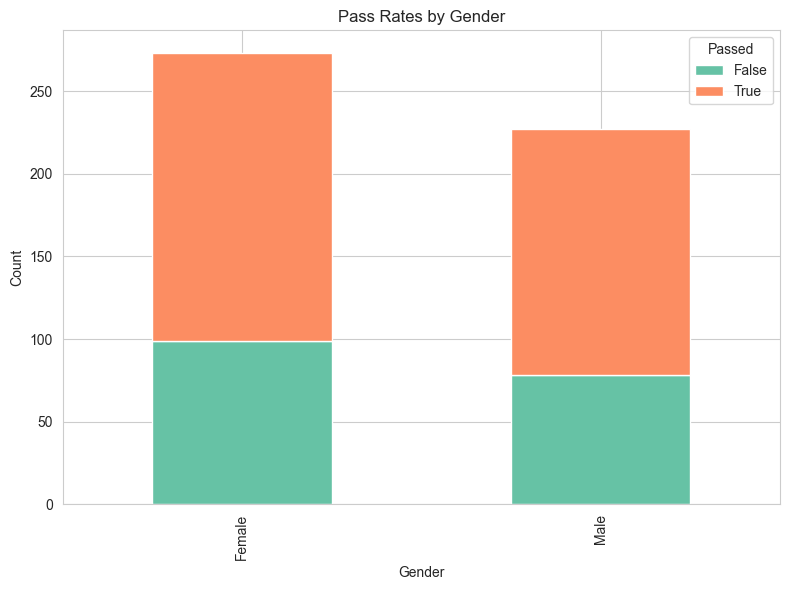

In [53]:
pd.crosstab(
    df_cat['gender'],  # the row variable
    df_cat['passed'],  # the column variable
    ).plot(
        kind='bar',
        stacked=True,
        figsize=(8, 6)
    )
plt.title('Pass Rates by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Passed', loc='upper right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q1 Categorical EDA

1. Produce two tabulations of pass rates against both internet access and parent education.  For internet access use `normalize=index` to get the proportions. Make sure your output is as percentages written to 2DP and set `margins=True` in both.
2. From these tabulations produce two bar charts.  Produce the same tables but without marginsFor internet access use `stacked=True`, and parent education use `stacked=False`.
3. Comment on the differences between the plots and discuss how you would use them differently.

---
**Solution:**

---

In Lab 4 we practiced producing multiplots for visually analyzing multiple variables efficiently.  In the following chunk we generate a multiplot of category countplots grouped by the categorical variable of interest.

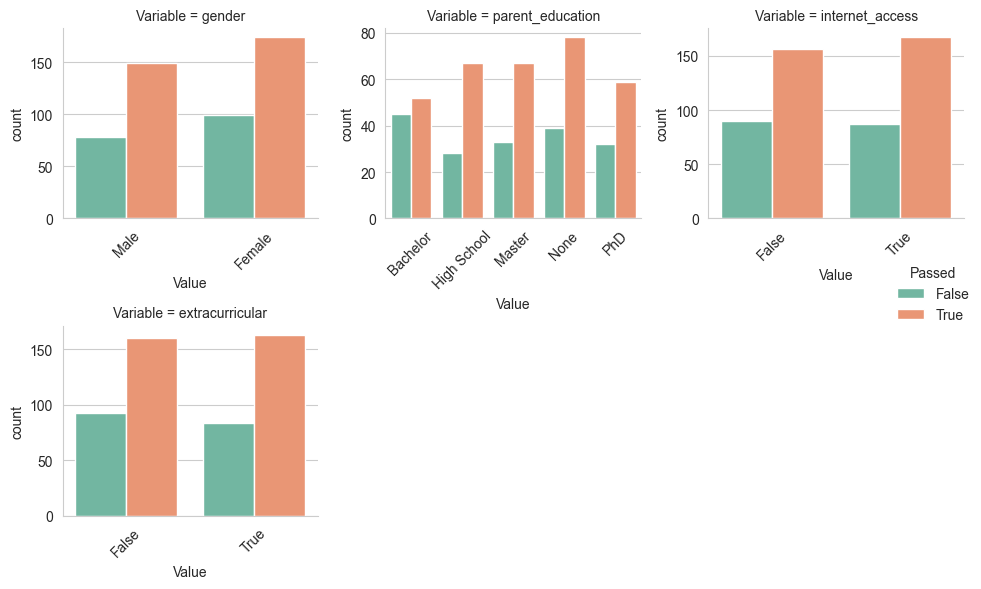

In [58]:
# Produce count plots for each categorical variable with passed as hue
plot_vars = [col for col in df_cat.columns if col != 'passed']
categorical_vars_melted = df_cat.melt(
    id_vars='passed',
    value_vars=plot_vars,
    var_name='Variable',
    value_name='Value'
)

def facet_countplot(data, color=None, **kwargs):
    sns.countplot(data=data, x='Value', hue='passed', **kwargs)

g = sns.FacetGrid(categorical_vars_melted, col='Variable', col_wrap=3, sharex=False, sharey=False)
g.map_dataframe(facet_countplot)
g.add_legend(title='Passed')
g.set_xticklabels(rotation=45)

plt.tight_layout()
plt.show()

We observe that the only evidence of any sort of relationship ia that students with parents who have Bachelors degrees appear to have a significantly worse pass rate than the rest of the student population.

### 2.2 Categorical and Quantitative

When exploring the relationship between quantitative variables and a categorical variable of interest we can produce a tabulation, this time of the summary statistics for each quantitative variable grouped by the variable of interest.  

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2 Categorical Quantitative Tabulation

Read the documentation on the `stack` function in `pandas` which is used to reshape a data frame frm wide to long by moving one or more column levels into the row index.  We shall be using this function to generate our table.

1. Produce a table of the summary statistics for each of the 5 quantitative variables grouped into whether they passed the class or not.  Your final table should have columns for variable, passed and then one column for each of the summary statistics produced by describe.  To produce this table you need to:

   1. Group `df` by `passed` and index only the columns with numerical variables not including final score.
   2. Apply the `describe` function to compute the summary statistics.
   3. Use the `stack` function with `levels=0` to double index rows by `passed` and variable.
   4. Relabel the index to `['passed', 'variable']`.
   5. use `reorder_levels` to switch the row index order to `['variable', 'passed']`.
   6. Apply `sort_index()` to sort and group the row indices.
   7. Round the values of the table to 2DP with `round()`.

2. Comment on the final table.  Do you see any evidence that 
---
**Solution:**

---

### 2.3 Quantitative Variables

Now let's consider quantitative variables exclusively.  We can compute the covariance and correlation matrices in `python` using `cov` and `corr` as demonstrated below:

In [69]:
cov_matrix = df_num.cov()
cov_matrix

,age,study_hours_per_week,attendance_rate,previous_score,final_score
age,2.057631,-0.678493,0.518410,-2.896100,-1.054549
study_hours_per_week,-0.678493,73.413483,-1.898745,-12.352337,105.894028
attendance_rate,0.518410,-1.898745,190.928300,-8.653178,51.131074
previous_score,-2.896100,-12.352337,-8.653178,358.627058,48.025772
final_score,-1.054549,105.894028,51.131074,48.025772,236.352305


In [70]:
corr_matrix = df_num.corr()
corr_matrix

,age,study_hours_per_week,attendance_rate,previous_score,final_score
age,1.000000,-0.055204,0.026155,-0.106613,-0.047819
study_hours_per_week,-0.055204,1.000000,-0.016038,-0.076127,0.803903
attendance_rate,0.026155,-0.016038,1.000000,-0.033069,0.240697
previous_score,-0.106613,-0.076127,-0.033069,1.000000,0.164958
final_score,-0.047819,0.803903,0.240697,0.164958,1.000000


From our correlation matrix we see negligible correlations except for a strong positive correlation between `study_hours_per_week` and `final_score`.  In `seaborn` we have several built in functions which produce visualizations of bivariate relationships between quantitative variables in a data set.  These include:

- `pairplot` which produces an array of scatter plots for each pair of quantitative variables.  By specifying `diag_kind=kde` the output displays the kernel density estimates for each variable on the diagonal.  This plot can be helpful for producing a quick summary of all of the bivariate relationships in the data.

- `heatmap` which, when provided with the 

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

### Q3 Pairplots and Heatmaps

1. Use `pairplot` in `seaborn` to produce a pairplot of all numerical variables besides `age`.
   - We omit `age` because although it has thus far been considered a quantitative variable, it only takes 5 values and therefore scatter plots and kernel density estimates will not provide any useful information.
2. Use `heatmap` using `corr_matrix` from above as an input to visualize the correlation matrix as a heatmap.
3. Comment on your findings and any relationships you see.

---
**Solution:**

---

We conclude by taking a closer look at the scatter plot of `final_score` against `study_hours_per_week`.  Out of interest we color points based on whether the individual passed the class or not to visualize the passing grade boundary which we previously determined was $\geq 50$.

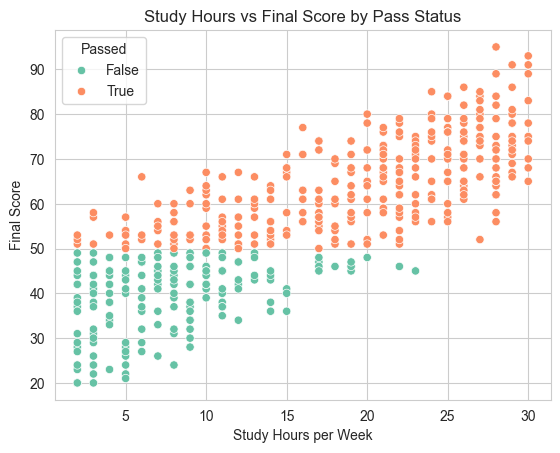

In [73]:
sns.scatterplot(data=df, x='study_hours_per_week', y='final_score', hue='passed')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score by Pass Status')
plt.legend(title='Passed', loc='upper left')
plt.show()

From our analysis we conclude that a sensible model choice might be to fit a simple linear regression model where we model final score against study hours per week.  We could also consider the addition of other variables (such as attendance rate or previous score) but would need to determine whether the added model complexity is worth any gains in modelling accuracy.  This will be something we will be discussing over the next few weeks in lecture.

---

## Submission Checklist

- Ensure you have completed all problems in the notebook.
- Clear your document code outputs and rerun the notebook, checking for any new errors.
- At the top of your notebook click more options -> export -> pdf.
  - Alternatively, export to html and save as a pdf.
- Make sure your pdf has all code chunks clearly visible and executed.
- Submit before the posted deadline. 